# Purpose

Compare the learnability of GO terms from composition-induced co-expression across manually curated tissue categories to their MGC Scores

In [1]:
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import gmean
import statsmodels.formula.api as smf

### Load GO Performance from composition-induced co-expression

In [2]:
def load_learnability(path:str)->pd.DataFrame:
	"""Load a dataframe containing info about a GO term's learnability from composition-induced co-expression

	Args:
		path (str): file path

	Returns:
		pd.DataFrame: df
	"""
	df = pd.read_csv(path,index_col=0)

	# extract and drop some metadata columns
	df['exp_type'] =df.organism_part.str.split("_").str.get(0)
	df['tissue'] =  df.organism_part.str.split("_").str.get(1)

	df = df[df['tissue']=='brain']
	df = df[df.loc[:,'variance']==0.05]
	df = df[df.loc[:,'exp_type']=='exp']

	df.drop('organism_part', axis =1 , inplace=True)
	df.drop('variance', axis =1 , inplace=True)

	return df
	
path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkSimulationOneProfile/data/boot_run_feb29/master_melted_df.csv.gz"
df = load_learnability(path)
df.head()

,index,bootstrap,auc,exp_type,tissue
1397,GO:0000045,3,0.537387,exp,brain
1398,GO:0000070,3,0.459143,exp,brain
1399,GO:0000077,3,0.468561,exp,brain
1400,GO:0000079,3,0.487572,exp,brain
1401,GO:0000082,3,0.488269,exp,brain


# Load MGC scores

In [3]:
def load_mgcs(path_to_json, mgcs_name:str)->pd.DataFrame:
	# Load the mgcs dictionary
	# Load the JSON file into a dictionary
	with open(path_to_json, 'r') as json_file:
		mgcs= json.load(json_file)
	# Convert the dictionary to a DataFrame
	mgcs = pd.DataFrame(list(mgcs.items()), columns=['gene', mgcs_name])
	return mgcs


brain_mgcs = pd.read_csv("../MGC/data/mgc_gini_brain.csv", index_col=0)
brain_mgcs

,mgc_gini
GO:0000045,0.205555
GO:0000070,0.261048
GO:0000077,0.189123
GO:0000079,0.386707
GO:0000082,0.261464
...,...
GO:2001237,0.326138
GO:2001238,0.402848
GO:2001240,0.471196
GO:2001243,0.322552


# Merge Learnability with GO MGC scores

In [4]:
# Merge GO learnability with curated category	
merged = df.merge(brain_mgcs, left_on='index',right_index=True)
merged

,index,bootstrap,auc,exp_type,tissue,mgc_gini
1397,GO:0000045,3,0.537387,exp,brain,0.205555
1397,GO:0000045,5,0.563274,exp,brain,0.205555
1397,GO:0000045,1,0.558774,exp,brain,0.205555
1397,GO:0000045,4,0.554706,exp,brain,0.205555
1397,GO:0000045,2,0.535530,exp,brain,0.205555
...,...,...,...,...,...,...
1396,GO:2001244,93,0.516547,exp,brain,0.334780
1396,GO:2001244,96,0.542822,exp,brain,0.334780
1396,GO:2001244,97,0.426631,exp,brain,0.334780
2793,GO:2001244,100,0.464323,exp,brain,0.334780


# Plot relationship between MGC and AUC

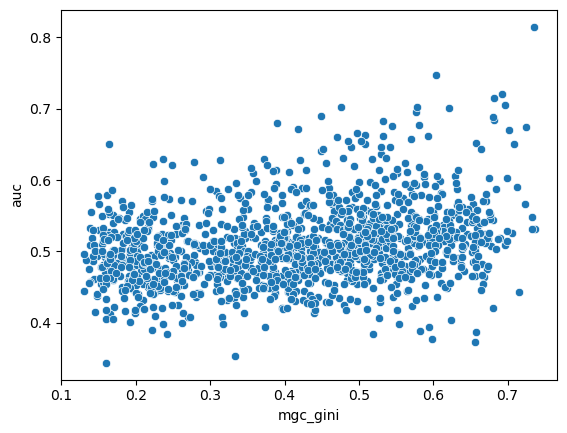

In [5]:
def scatr(merged):
	agg = merged.groupby("index")[['auc','mgc_gini']].mean()
	sns.scatterplot(agg, x = 'mgc_gini', y = 'auc')
	plt.show()
scatr(merged)

In [6]:
from statsmodels.formula.api import mixedlm
import numpy as np
def model_sim(merged):
	powers = [1,2]  # You can change this range
	for p in powers:
		merged[f'gini_pow_{p}'] = merged['mgc_gini'] ** p

	power_terms = [f'gini_pow_{p}' for p in powers]

	# Join into one formula string
	formula = 'auc ~ ' + ' + '.join(power_terms)
	print(formula)
	merged['GO']= merged.loc[:,'index']
	print(merged.head())
	model = mixedlm(formula = formula, data = merged, groups = merged['GO']).fit()
	pred = model.predict(merged)
	merged['pred'] = pred
	return model, merged	
model, merged = model_sim(merged)
model.summary()

auc ~ gini_pow_1 + gini_pow_2
           index  bootstrap       auc exp_type tissue  mgc_gini  gini_pow_1  \
1397  GO:0000045          3  0.537387      exp  brain  0.205555    0.205555   
1397  GO:0000045          5  0.563274      exp  brain  0.205555    0.205555   
1397  GO:0000045          1  0.558774      exp  brain  0.205555    0.205555   
1397  GO:0000045          4  0.554706      exp  brain  0.205555    0.205555   
1397  GO:0000045          2  0.535530      exp  brain  0.205555    0.205555   

      gini_pow_2          GO  
1397    0.042253  GO:0000045  
1397    0.042253  GO:0000045  
1397    0.042253  GO:0000045  
1397    0.042253  GO:0000045  
1397    0.042253  GO:0000045  


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: auc        
No. Observations: 139600  Method:             REML       
No. Groups:       1396    Scale:              0.0012     
Min. group size:  100     Log-Likelihood:     265633.3720
Max. group size:  100     Converged:          Yes        
Mean group size:  100.0                                  
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.491    0.009 52.123 0.000  0.473  0.510
gini_pow_1     -0.039    0.050 -0.777 0.437 -0.136  0.059
gini_pow_2      0.168    0.060  2.788 0.005  0.050  0.286
Group Var       0.003    0.003                           
=========================================================

"""

                 auc  mgc_gini      pred
index                                   
GO:0000045  0.545295  0.205555  0.490446
GO:0000070  0.500938  0.261048  0.492646
GO:0000077  0.487778  0.189123  0.489993
GO:0000079  0.471284  0.386707  0.501449
GO:0000082  0.473454  0.261464  0.492666
...              ...       ...       ...
GO:2001237  0.474204  0.326138  0.496544
GO:2001238  0.420278  0.402848  0.502965
GO:2001240  0.477814  0.471196  0.510350
GO:2001243  0.535729  0.322552  0.496292
GO:2001244  0.492770  0.334780  0.497169

[1396 rows x 3 columns]


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


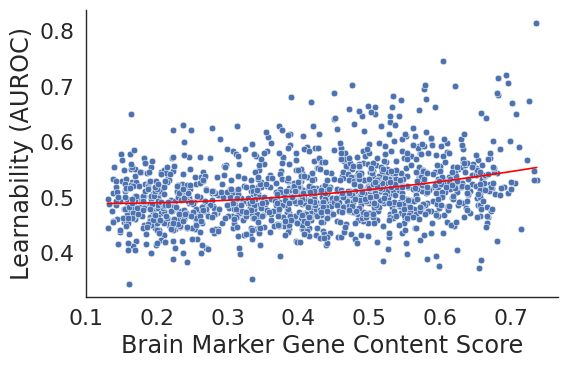

In [7]:
def plot_comp(merged):
	sns.set(style="white")# Set up plot parameters
	sns.set_context("paper", font_scale=1.8)  # Slightly larger text for clarity
	plt.figure(figsize=(6, 4))  # Adjust figure size    

	agg = merged.groupby("index")[['auc','mgc_gini', 'pred']].mean()
	print(agg)
	sns.scatterplot(agg, x = 'mgc_gini', y = 'auc')
	sns.lineplot(agg, x = 'mgc_gini', y = 'pred', color = 'red')

	plt.ylabel("Learnability (AUROC)")
	plt.xlabel("Brain Marker Gene Content Score")

	plt.tight_layout()
	sns.despine()

	# plt.savefig("figs/AUC_MGC_Brain.png", dpi = 300)
	# plt.savefig("figs/AUC_MGC_Brain.svg", dpi = 300)
	plt.show()
plot_comp(merged)

In [8]:
merged

,index,bootstrap,auc,exp_type,tissue,mgc_gini,gini_pow_1,gini_pow_2,GO,pred
1397,GO:0000045,3,0.537387,exp,brain,0.205555,0.205555,0.042253,GO:0000045,0.490446
1397,GO:0000045,5,0.563274,exp,brain,0.205555,0.205555,0.042253,GO:0000045,0.490446
1397,GO:0000045,1,0.558774,exp,brain,0.205555,0.205555,0.042253,GO:0000045,0.490446
1397,GO:0000045,4,0.554706,exp,brain,0.205555,0.205555,0.042253,GO:0000045,0.490446
1397,GO:0000045,2,0.535530,exp,brain,0.205555,0.205555,0.042253,GO:0000045,0.490446
...,...,...,...,...,...,...,...,...,...,...
1396,GO:2001244,93,0.516547,exp,brain,0.334780,0.334780,0.112078,GO:2001244,0.497169
1396,GO:2001244,96,0.542822,exp,brain,0.334780,0.334780,0.112078,GO:2001244,0.497169
1396,GO:2001244,97,0.426631,exp,brain,0.334780,0.334780,0.112078,GO:2001244,0.497169
2793,GO:2001244,100,0.464323,exp,brain,0.334780,0.334780,0.112078,GO:2001244,0.497169


# Look at the same relationship but using models trained on composition-corrected co-expression.

In [52]:
import pandas as pd
import os
def load_regressed_performance(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/deconvolutingBulk/data/dev/july_boot_29")->pd.DataFrame:
    """Loads performance from 62 simulations where composition variance from brain markers was regressed out

    Args:
        path (str, optional): path to regression performance directory

    Returns:
        pd.DataFrame: Dataframe that has performance for bulk brain with regressed comp
    """

    lo_dirs = os.listdir(path)
    lo_potential_files = [f"{path}/{dir}/melted_EGAD.csv" for dir in lo_dirs]

    def filter_existing_paths(paths):
        """Filter out paths that do not exist."""
        existing_paths = [path for path in paths if os.path.exists(path)]
        return existing_paths
    lo_files = filter_existing_paths(lo_potential_files)
    
    lo_dfs = [pd.read_csv(file, index_col=0) for file in lo_files]

    def add_boot_col(lo_dfs):
        lo_new_dfs = []
        for i,df in enumerate(lo_dfs):
            df['boot']=i
            lo_new_dfs.append(df)
        return lo_new_dfs
    lo_dfs = add_boot_col(lo_dfs=lo_dfs)
    
    df = pd.concat(lo_dfs, axis = 0)
    return df #df_grouped

regressed = load_regressed_performance()
regressed = regressed.loc[:,['auc','type']].reset_index().groupby(['index','type']).median().reset_index() # aggragate over repeats
regressed = regressed.loc[:,['type','auc', 'index']].pivot(index='index', columns='type', values='auc').reset_index()
regressed.head()

type,index,markers,random
0,GO:0000045,0.537546,0.548890
1,GO:0000070,0.668666,0.691849
2,GO:0000077,0.567345,0.535158
3,GO:0000079,0.595469,0.548815
4,GO:0000082,0.527736,0.507692


In [53]:
def load_GO_curations(patho_to_curations="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv"):
	GO_curations = pd.read_csv(patho_to_curations, sep = "\t")

	def melt_curations(df:pd.DataFrame)->pd.DataFrame:
		"""
		create a new column that is a melted version of the GO term curations

		Parameters:
		- df: pandas DataFrame

		Returns:
		- pandas DataFrame with a new column 'meta' indicating the curation category of the GO term
		"""
		# Create a new column using conditions
		meta = df.apply(lambda row: 'Brain' if row['BrainAffiliated'] == 'T' else 'Non Brain', axis = 1)
		df['meta']=meta
		
		return df
	GO_curations = melt_curations(GO_curations)
	return GO_curations

GO_curations = load_GO_curations()
GO_curations.meta.value_counts()

meta
Non Brain    1294
Brain         102
Name: count, dtype: int64

In [54]:
merged_reg = regressed.merge(brain_mgcs, left_on='index',right_index=True)
merged_reg = merged_reg.merge(GO_curations, left_on='index', right_on='id')
merged_reg.head()

,index,markers,random,mgc_gini,id,name,namespace,CTAffiliated,BrainAffiliated,PBMCAffiliated,def,meta
0,GO:0000045,0.537546,0.548890,0.205555,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain
1,GO:0000070,0.668666,0.691849,0.261048,GO:0000070,mitotic sister chromatid segregation,biological_process,F,F,F,The cell cycle process in which replicated hom...,Non Brain
2,GO:0000077,0.567345,0.535158,0.189123,GO:0000077,DNA damage checkpoint signaling,biological_process,F,F,F,A signal transduction process that contributes...,Non Brain
3,GO:0000079,0.595469,0.548815,0.386707,GO:0000079,regulation of cyclin-dependent protein serine/...,biological_process,F,F,F,"Any process that modulates the frequency, rate...",Non Brain
4,GO:0000082,0.527736,0.507692,0.261464,GO:0000082,G1/S transition of mitotic cell cycle,biological_process,F,F,F,The mitotic cell cycle transition by which a c...,Non Brain


<Axes: xlabel='random', ylabel='markers'>

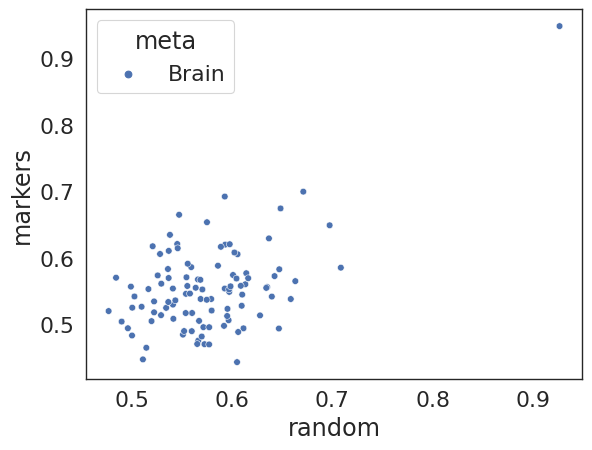

In [55]:
sns.scatterplot(merged_reg[merged_reg['meta']=='Brain'], x = 'random', y = 'markers', hue = 'meta')

In [56]:
brain= merged_reg[merged_reg['meta']=='Brain']
brain.loc[:,['markers','random','mgc_gini']].corr()

# I think I need to isolate the analysis to only high mgc GO terms, or just brain GO Terms both

,markers,random,mgc_gini
markers,1.000000,0.534785,0.148469
random,0.534785,1.000000,0.259509
mgc_gini,0.148469,0.259509,1.000000


In [57]:
merged_reg.sort_values('random', ascending=False)

,index,markers,random,mgc_gini,id,name,namespace,CTAffiliated,BrainAffiliated,PBMCAffiliated,def,meta
1088,GO:0050911,0.949023,0.926638,0.735747,GO:0050911,detection of chemical stimulus involved in sen...,biological_process,T,T,F,The series of events involved in the perceptio...,Brain
1150,GO:0052695,0.925476,0.908117,0.651645,GO:0052695,cellular glucuronidation,biological_process,F,F,F,The modification of an organic chemical by the...,Non Brain
95,GO:0002181,0.861283,0.907969,0.207721,GO:0002181,cytoplasmic translation,biological_process,F,F,F,The chemical reactions and pathways resulting ...,Non Brain
120,GO:0003341,0.898882,0.865095,0.428650,GO:0003341,cilium movement,biological_process,T,F,F,"The directed, self-propelled movement of a cil...",Non Brain
129,GO:0006120,0.811908,0.847849,0.169135,GO:0006120,"mitochondrial electron transport, NADH to ubiq...",biological_process,F,F,F,The transfer of electrons from NADH to ubiquin...,Non Brain
...,...,...,...,...,...,...,...,...,...,...,...,...
1267,GO:0072332,0.518550,0.445826,0.281898,GO:0072332,intrinsic apoptotic signaling pathway by p53 c...,biological_process,F,F,F,The series of molecular signals in which an in...,Non Brain
716,GO:0032967,0.517219,0.439854,0.597946,GO:0032967,positive regulation of collagen biosynthetic p...,biological_process,F,F,F,Any process that activates or increases the fr...,Non Brain
1009,GO:0048260,0.476235,0.436705,0.552781,GO:0048260,positive regulation of receptor-mediated endoc...,biological_process,F,F,F,Any process that activates or increases the fr...,Non Brain
1335,GO:1901223,0.607580,0.433108,0.519639,GO:1901223,negative regulation of non-canonical NF-kappaB...,biological_process,F,F,F,"Any process that stops, prevents or reduces th...",Non Brain


In [58]:
merged_reg.groupby('meta')[["markers",	"random"]].corr()

markers    random
meta                                 
Brain     markers  1.000000  0.534785
          random   0.534785  1.000000
Non Brain markers  1.000000  0.679975
          random   0.679975  1.000000

In [59]:
merged_reg

,index,markers,random,mgc_gini,id,name,namespace,CTAffiliated,BrainAffiliated,PBMCAffiliated,def,meta
0,GO:0000045,0.537546,0.548890,0.205555,GO:0000045,autophagosome assembly,biological_process,F,F,F,The formation of a double membrane-bounded str...,Non Brain
1,GO:0000070,0.668666,0.691849,0.261048,GO:0000070,mitotic sister chromatid segregation,biological_process,F,F,F,The cell cycle process in which replicated hom...,Non Brain
2,GO:0000077,0.567345,0.535158,0.189123,GO:0000077,DNA damage checkpoint signaling,biological_process,F,F,F,A signal transduction process that contributes...,Non Brain
3,GO:0000079,0.595469,0.548815,0.386707,GO:0000079,regulation of cyclin-dependent protein serine/...,biological_process,F,F,F,"Any process that modulates the frequency, rate...",Non Brain
4,GO:0000082,0.527736,0.507692,0.261464,GO:0000082,G1/S transition of mitotic cell cycle,biological_process,F,F,F,The mitotic cell cycle transition by which a c...,Non Brain
...,...,...,...,...,...,...,...,...,...,...,...,...
1391,GO:2001237,0.489339,0.552745,0.326138,GO:2001237,negative regulation of extrinsic apoptotic sig...,biological_process,F,F,F,"Any process that stops, prevents or reduces th...",Non Brain
1392,GO:2001238,0.593244,0.555755,0.402848,GO:2001238,positive regulation of extrinsic apoptotic sig...,biological_process,F,F,F,Any process that activates or increases the fr...,Non Brain
1393,GO:2001240,0.542131,0.534804,0.471196,GO:2001240,negative regulation of extrinsic apoptotic sig...,biological_process,F,F,F,"Any process that stops, prevents or reduces th...",Non Brain
1394,GO:2001243,0.589597,0.561297,0.322552,GO:2001243,negative regulation of intrinsic apoptotic sig...,biological_process,F,F,F,"Any process that stops, prevents or reduces th...",Non Brain


In [60]:
melted_reg = merged_reg.melt(id_vars = ['index','mgc_gini', 'meta'], value_vars=['markers','random'])
melted_reg['variable'] = pd.Categorical(melted_reg['variable'], ordered=True, categories = ['random','markers']) 
powers = [1,2]  # You can change this range
for p in powers:
    melted_reg[f'gini_pow_{p}'] = melted_reg['mgc_gini'] ** p

power_terms = [f'gini_pow_{p}' for p in powers]
interaction_terms = [f'variable * {term}' for term in power_terms]

# Join into one formula string
formula = 'value ~ ' + ' + '.join(interaction_terms)
formula

'value ~ variable * gini_pow_1 + variable * gini_pow_2'

In [61]:
model = smf.ols(formula = formula, data = melted_reg).fit()

In [62]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  value   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     115.2
Date:                Thu, 29 May 2025   Prob (F-statistic):          5.58e-111
Time:                        16:46:20   Log-Likelihood:                 3803.4
No. Observations:                2792   AIC:                            -7595.
Df Residuals:                    2786   BIC:                            -7559.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.7041      0.012     60.971      0.000       0.681       0.727
variable[T.markers]                0.0042      0.016      0.255      0.799      -0.028       0.036
gini_pow_1                        -0.7979      0.061    -13.076      0.000      -0.918      -0.678
variable[T.markers]:gini_pow_1    -0.0856      0.086     -0.992      0.321      -0.255       0.084
gini_pow_2                         0.9679      0.074     13.120      0.000       0.823       1.113
variable[T.markers]:gini_pow_2     0.2426      0.104      2.325      0.020       0.038       0.447
==============================================================================
Omnibus:                      640.934   Durbin-Watson:                   1.924
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1872.762
Skew:                           1.180   Prob(JB):                         0.00
Kurtosis:                       6.244   Cond. No.                         167.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [63]:
preds = model.predict(melted_reg).values
melted_reg['preds'] = preds

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option i

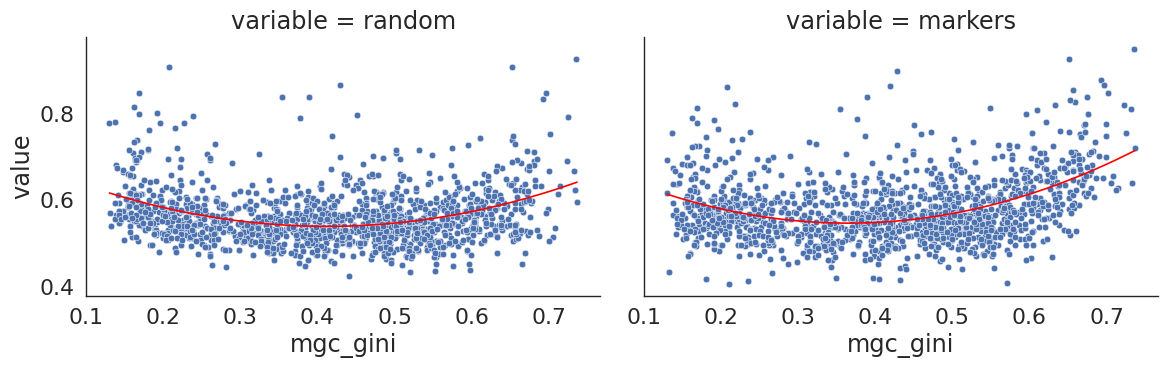

In [64]:
# Create the FacetGrid plot
g = sns.FacetGrid(melted_reg, col="variable", col_wrap=2, height=4, aspect=1.5)

# Map the scatterplot
g.map(sns.scatterplot, 'mgc_gini', 'value')
g.map(sns.lineplot, 'mgc_gini', 'preds', color = 'red')
# Access the axes of the FacetGrid (flat list of matplotlib Axes)
axes = g.axes.flat  # .flat makes it iterable as a 1D array

# Plot the line on the first facet (index 0)
# sns.lineplot(x=gini_x, y=marker_preds, ax=axes[0], color='red', linewidth=2, label='Model')
# sns.lineplot(x=gini_x, y=random_preds, ax=axes[1], color='red', linewidth=2, label='Model')


# Adjust layout and display
g.set_axis_labels('mgc_gini', 'value')
plt.show()

# Compare bulk to MGCs

In [22]:
def load_bulk(path:str) -> pd.DataFrame:
	df = pd.read_csv(path, index_col=0)
	return df
	
bulk = load_bulk("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkEGADPipeline/data/splitOPs1/EGAD/melted_dfs/Brain_split.csv_melted_EGADs.csv.gz")

In [23]:
merged_bulk = pd.merge(bulk, brain_mgcs, left_on='index', right_index = True)
merged_bulk.head()

,index,bootstrap,auc,mgc_gini
0,GO:0002250,29,0.735470,0.639029
0,GO:0002250,14,0.696034,0.639029
0,GO:0002250,20,0.692674,0.639029
0,GO:0002250,3,0.686195,0.639029
0,GO:0002250,17,0.689277,0.639029


In [25]:
from statsmodels.formula.api import mixedlm

def model_bulk(bulk):
	
	powers = [1,2]  # You can change this range
	for p in powers:
		bulk[f'gini_pow_{p}'] = bulk['mgc_gini'] ** p

	power_terms = [f'gini_pow_{p}' for p in powers]

	# Join into one formula string
	formula = 'auc ~ ' + ' + '.join(power_terms)
	model = mixedlm(formula = formula, data = bulk, groups = bulk['index']).fit()
	bulk_pred = model.predict(bulk)
	bulk['pred'] = bulk_pred
	return model, bulk

bulk_model, merged_bulk = model_bulk(merged_bulk)
bulk_model.summary()

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
==========================================================
Model:            MixedLM Dependent Variable: auc         
No. Observations: 1369000 Method:             REML        
No. Groups:       1369    Scale:              0.0017      
Min. group size:  1000    Log-Likelihood:     2416162.8193
Max. group size:  1000    Converged:          Yes         
Mean group size:  1000.0                                  
----------------------------------------------------------
               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept       0.696    0.012  57.384 0.000  0.672  0.720
gini_pow_1     -0.772    0.064 -12.046 0.000 -0.898 -0.646
gini_pow_2      1.128    0.077  14.551 0.000  0.976  1.280
Group Var       0.004    0.004                            
==========================================================

"""

In [76]:
bulk_model.pvalues

Intercept      0.000000e+00
gini_pow_1     2.043095e-33
gini_pow_2     5.785692e-48
Group Var     4.864375e-151
dtype: float64

### Plot

/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


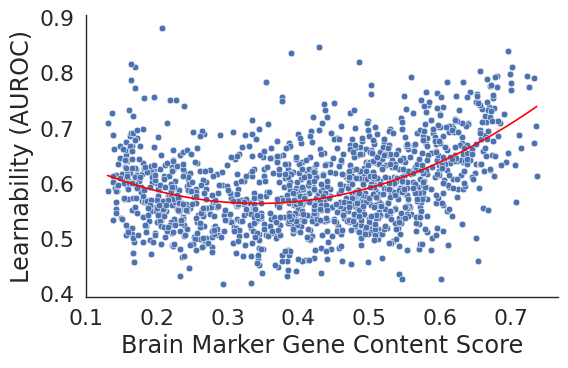

In [26]:
def plot_bulk(merged):
	sns.set(style="white")# Set up plot parameters
	sns.set_context("paper", font_scale=1.8)  # Slightly larger text for clarity
	plt.figure(figsize=(6, 4))  # Adjust figure size    

	agg = merged.groupby("index")[['auc','mgc_gini', 'pred']].mean()
	sns.scatterplot(agg, x = 'mgc_gini', y = 'auc')
	sns.lineplot(agg, x = 'mgc_gini', y = 'pred', color = 'red')

	plt.ylabel("Learnability (AUROC)")
	plt.xlabel("Brain Marker Gene Content Score")

	plt.tight_layout()
	sns.despine()

	plt.savefig("figs/AUC_MGC_Brain_bulk.png", dpi = 300)
	plt.savefig("figs/AUC_MGC_Brain_bulk.svg", dpi = 300)
	plt.show()

plot_bulk(merged_bulk)

Compare bulk to Reg MGC

In [68]:
melted_reg_markers = melted_reg[melted_reg.loc[:,'variable']=='markers']
melted_reg_markers

,index,mgc_gini,meta,variable,value,gini_pow_1,gini_pow_2,preds
0,GO:0000045,0.205555,Non Brain,markers,0.537546,0.205555,0.042253,0.577760
1,GO:0000070,0.261048,Non Brain,markers,0.668666,0.261048,0.068146,0.560076
2,GO:0000077,0.189123,Non Brain,markers,0.567345,0.189123,0.035767,0.584427
3,GO:0000079,0.386707,Non Brain,markers,0.595469,0.386707,0.149543,0.547588
4,GO:0000082,0.261464,Non Brain,markers,0.527736,0.261464,0.068363,0.559971
...,...,...,...,...,...,...,...,...
1391,GO:2001237,0.326138,Non Brain,markers,0.489339,0.326138,0.106366,0.548835
1392,GO:2001238,0.402848,Non Brain,markers,0.593244,0.402848,0.162287,0.548755
1393,GO:2001240,0.471196,Non Brain,markers,0.542131,0.471196,0.222026,0.560685
1394,GO:2001243,0.322552,Non Brain,markers,0.589597,0.322552,0.104040,0.549187


<Axes: xlabel='mgc_gini', ylabel='diff'>

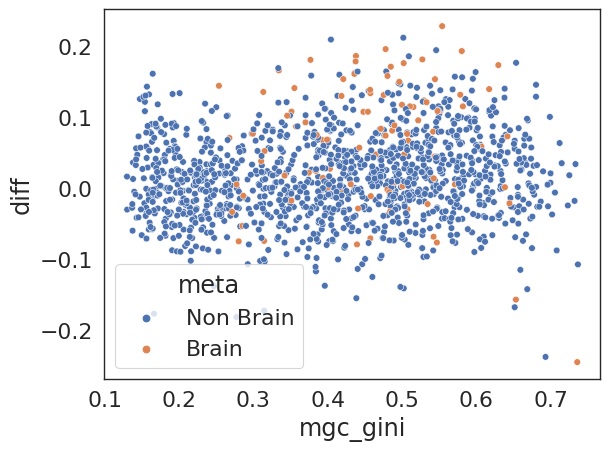

In [74]:
bulk_merged = pd.merge(merged_bulk_agg, melted_reg_markers, left_index=True, right_on='index')
bulk_merged['diff'] = bulk_merged['auc'] - bulk_merged['value']#positive means term was more learnable in bulk
# negative means term was more learnable when markers were corrected
#hope to see that terms with large diffs were more learnable
sns.scatterplot(bulk_merged, x = 'mgc_gini', y = 'diff', hue = 'meta')
# sns.scatterplot(bulk_merged, x = 'auc', y = 'value')

<Axes: xlabel='meta', ylabel='diff'>

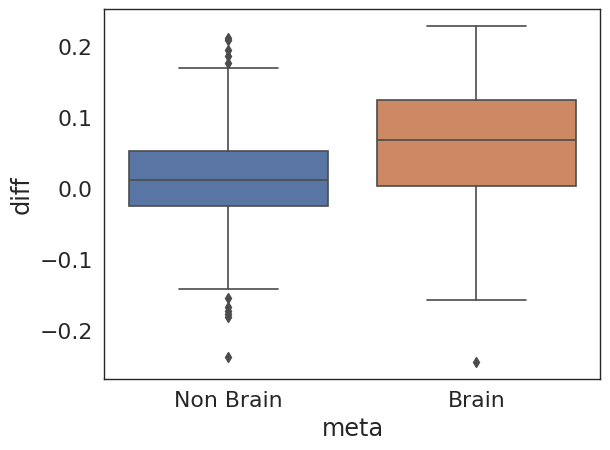

In [75]:
sns.boxplot(bulk_merged, x = 'meta', y = 'diff')

In [37]:
merged_bulk_agg

index
GO:0000045    0.533385
GO:0000070    0.622184
GO:0000077    0.532863
GO:0000079    0.530116
GO:0000082    0.498722
                ...   
GO:2001237    0.506879
GO:2001238    0.682347
GO:2001240    0.558035
GO:2001243    0.567128
GO:2001244    0.649389
Name: auc, Length: 1369, dtype: float64

# ARchived


In [ ]:
assert False

AssertionError: 

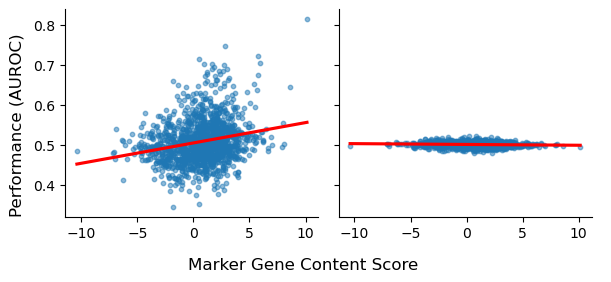

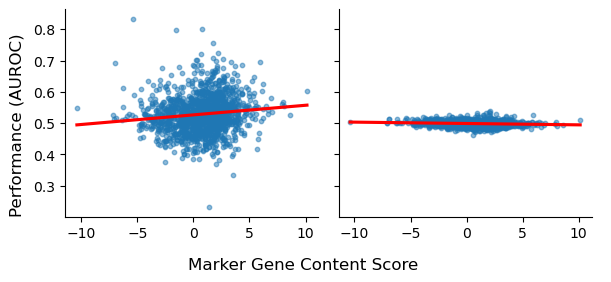

In [ ]:
def plot(GO_learnabilty_df_mean):
	# Assuming brain_master is your DataFrame
	# Create a seaborn FacetGrid
	g = sns.FacetGrid(GO_learnabilty_df_mean, row='tissue', col='exp_type', margin_titles=False, col_order = ['exp','cntrl'])

	# Map the scatterplot with line of best fit for 'auc' vs 'pbmcMGES'
	g.map(sns.regplot, "wilcoxon_stat", 'auc', scatter_kws={'s':10, 'alpha':0.5}, line_kws={'color':'red'}, ci=None)
	# g.map(sns.regplot, 'brainMGC', 'auc', scatter_kws={'s':10}, line_kws={'color':'red'}, ci=None)

	# Map the scatterplot with line of best fit for 'auc' vs 'brainMGES'
	# g.map(sns.regplot, 'wilcox_MGES', 'auc', scatter_kws={'s':10}, line_kws={'color':'blue'}, ci=None)
	# g.map(sns.regplot, 'logfc_MGES', 'auc', scatter_kws={'s':10}, line_kws={'color':'green'}, ci=None)
	g.set_titles('')  # Remove facet titles
	g.set(xlabel='', ylabel='')  # Remove axis labels

	# Add legends and adjust the plot
	g.add_legend()# Add single global x and y labels
	g.fig.text(0.5, 0.02, 'Marker Gene Content Score', ha='center', fontsize=12)  # X-axis labe
	g.fig.text(0.02, 0.5, 'Performance (AUROC)', va='center', rotation=90, fontsize=12)  # Y-axis label

	# Show the plot
	# plt.tight_layout()
	plt.savefig("figs/AUC_MGC.png", dpi = 300 )
	plt.show()


plot(GO_learnabilty_df[GO_learnabilty_df.loc[:,"tissue"]=='brain'])
plot(GO_learnabilty_df[GO_learnabilty_df.loc[:,"tissue"]=='pbmc'])

In [ ]:
model = smf.ols('auc ~ wilcoxon_stat * tissue', data=GO_learnabilty_df_mean[GO_learnabilty_df_mean.loc[:,'exp_type']=='exp']).fit()

# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    auc   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     61.41
Date:                Thu, 13 Mar 2025   Prob (F-statistic):           1.92e-38
Time:                        12:09:08   Log-Likelihood:                 4123.4
No. Observations:                2792   AIC:                            -8239.
Df Residuals:                    2788   BIC:                            -8215.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [ ]:
test = GO_learnabilty_df[GO_learnabilty_df.loc[:,"tissue"]=='brain']
test = test[test.loc[:,'exp_type']=="exp"]
rho = test[['wilcoxon_stat', 'auc']].corr(method="spearman").iloc[0, 1]
spearman_r2 = rho ** 2
spearman_r2

0.04975113732752261

In [ ]:
GO_learnabilty_df

,index,exp_type,tissue,auc,mgc_gini,wilcoxon_stat,p_value,mgc_gini_others
0,GO:0000045,cntrl,brain,0.495079,0.031512,-3.363546,0.000769,0.058856
1,GO:0000045,cntrl,pbmc,0.485234,0.031512,-3.363546,0.000769,0.058856
2,GO:0000045,exp,brain,0.545295,0.031512,-3.363546,0.000769,0.058856
3,GO:0000045,exp,pbmc,0.561590,0.031512,-3.363546,0.000769,0.058856
4,GO:0000070,cntrl,brain,0.505884,0.046846,-1.635288,0.101989,0.058747
...,...,...,...,...,...,...,...,...
5579,GO:2001243,exp,pbmc,0.509225,0.082768,0.411250,0.680889,0.058674
5580,GO:2001244,cntrl,brain,0.494293,0.070580,-0.451867,0.651364,0.058678
5581,GO:2001244,cntrl,pbmc,0.492240,0.070580,-0.451867,0.651364,0.058678
5582,GO:2001244,exp,brain,0.492770,0.070580,-0.451867,0.651364,0.058678


# Add GO Term relatedness

In [ ]:
def load_GO_curations(patho_to_curations="../data/GOCUrations.tsv"):
	GO_curations = pd.read_csv(patho_to_curations, sep = "\t")

	def melt_curations(df:pd.DataFrame)->pd.DataFrame:
		"""
		create a new column that is a melted version of the GO term curations

		Parameters:
		- df: pandas DataFrame

		Returns:
		- pandas DataFrame with a new column 'meta' indicating the curation category of the GO term
		"""
		# Create a new column using conditions
		meta = df.apply(lambda row: 'Brain' if row['BrainAffiliated'] == 'T' else ('PBMC' if row['PBMCAffiliated'] == 'T' else "Neither"), axis=1)
		df['meta']=meta
		
		return df
	GO_curations = melt_curations(GO_curations)
	return GO_curations

GO_curations = load_GO_curations()
GO_curations

,id,name,CTAffiliated,BrainAffiliated,PBMCAffiliated,def,meta
0,GO:0000045,autophagosome assembly,F,F,F,The formation of a double membrane-bounded str...,Neither
1,GO:0000070,mitotic sister chromatid segregation,F,F,F,The cell cycle process in which replicated hom...,Neither
2,GO:0000077,DNA damage checkpoint signaling,F,F,F,A signal transduction process that contributes...,Neither
3,GO:0000079,regulation of cyclin-dependent protein serine/...,F,F,F,"Any process that modulates the frequency, rate...",Neither
4,GO:0000082,G1/S transition of mitotic cell cycle,F,F,F,The mitotic cell cycle transition by which a c...,Neither
...,...,...,...,...,...,...,...
1391,GO:2001237,negative regulation of extrinsic apoptotic sig...,F,F,F,"Any process that stops, prevents or reduces th...",Neither
1392,GO:2001238,positive regulation of extrinsic apoptotic sig...,F,F,F,Any process that activates or increases the fr...,Neither
1393,GO:2001240,negative regulation of extrinsic apoptotic sig...,F,F,F,"Any process that stops, prevents or reduces th...",Neither
1394,GO:2001243,negative regulation of intrinsic apoptotic sig...,F,F,F,"Any process that stops, prevents or reduces th...",Neither


In [ ]:
GO_learnabilty_df = GO_learnabilty_df.merge(GO_curations, left_on='index', right_on='id')
GO_learnabilty_df['meta'] = pd.Categorical(GO_learnabilty_df['meta'], categories = ['Neither','Brain', 'PBMC'])

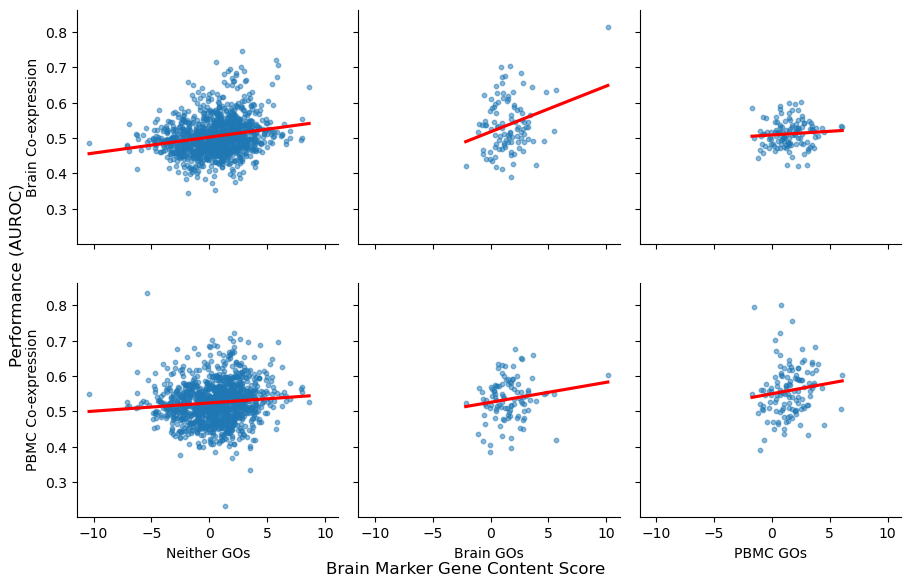

In [ ]:
def plot(GO_learnabilty_df_mean):
	# Assuming brain_master is your DataFrame
	# Create a seaborn FacetGrid
	g = sns.FacetGrid(GO_learnabilty_df_mean, row='tissue', col='meta', margin_titles=False)

	# Map the scatterplot with line of best fit for 'auc' vs 'pbmcMGES'
	g.map(sns.regplot, 'wilcoxon_stat', 'auc', scatter_kws={'s':10, 'alpha':0.5}, line_kws={'color':'red'}, ci=None)
	# g.map(sns.regplot, 'brainMGC', 'auc', scatter_kws={'s':10}, line_kws={'color':'red'}, ci=None)

	# Map the scatterplot with line of best fit for 'auc' vs 'brainMGES'
	# g.map(sns.regplot, 'wilcox_MGES', 'auc', scatter_kws={'s':10}, line_kws={'color':'blue'}, ci=None)
	# g.map(sns.regplot, 'logfc_MGES', 'auc', scatter_kws={'s':10}, line_kws={'color':'green'}, ci=None)
	g.set_titles('')  # Remove facet titles

	
	g.axes[1,0].set_xlabel('Neither GOs')
	g.axes[1,1].set_xlabel('Brain GOs')
	g.axes[1,2].set_xlabel('PBMC GOs')
	g.axes[0,0].set_ylabel('Brain Co-expression')
	g.axes[1,0].set_ylabel('PBMC Co-expression')




	# g.set(col_labels=['Neither', 'PBMC', 'Brain'])

	# Add legends and adjust the plot
	g.add_legend()# Add single global x and y labels
	tissue = 'Brain'
	g.fig.text(0.5, 0.002, f'{tissue} Marker Gene Content Score', ha='center', fontsize=12)  # X-axis labe
	g.fig.text(0.0, 0.5, 'Performance (AUROC)', va='center', rotation=90, fontsize=12)  # Y-axis label

	# Show the plot
	# plt.tight_layout()
	plt.savefig(f"figs/AUC_MGC_{tissue}.png", dpi = 300 )
	plt.show()

plot(GO_learnabilty_df[GO_learnabilty_df.loc[:,'exp_type']=='exp'])



# Get Stats for relationship

In [ ]:
# GO_learnability_df_mean_stats = GO_learnabilty_df_mean[GO_learnabilty_df_mean.loc[:,'tissue']=='brain']
# GO_learnability_df_mean_stats = GO_learnabilty_df_mean[GO_learnabilty_df_mean.loc[:,'tissue']=='pbmc']
GO_learnability_df_mean_stats = GO_learnabilty_df_mean.copy()
GO_learnability_df_mean_stats['meta'] = pd.Categorical(GO_learnability_df_mean_stats['meta'], categories = ['Neither','PBMC','Brain'])

In [ ]:
model = smf.ols('auc ~ meta * mgc_gini', data=GO_learnability_df_mean_stats[GO_learnability_df_mean_stats.loc[:,'exp_type']=='exp']).fit()

# Print the summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    auc   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     43.69
Date:                Fri, 07 Mar 2025   Prob (F-statistic):           1.68e-43
Time:                        14:06:16   Log-Likelihood:                 4139.5
No. Observations:                2792   AIC:                            -8267.
Df Residuals:                    2786   BIC:                            -8231.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Fit the model
model = smf.ols('auc ~ meta * mgc_gini * tissue', data=GO_learnability_df_mean_stats[GO_learnability_df_mean_stats.loc[:,'exp_type']=='exp']).fit()

# Perform ANOVA on the fitted model
anova_results = sm.stats.anova_lm(model)

# Print the ANOVA table
print(anova_results)


                          df    sum_sq   mean_sq           F        PR(>F)
meta                     2.0  0.162942  0.081471   28.367502  6.370583e-13
tissue                   1.0  0.296145  0.296145  103.115162  8.187232e-24
meta:tissue              2.0  0.072649  0.036325   12.647969  3.403276e-06
mgc_gini                 1.0  0.446999  0.446999  155.641337  8.511905e-35
meta:mgc_gini            2.0  0.050766  0.025383    8.838097  1.492156e-04
mgc_gini:tissue          1.0  0.041287  0.041287   14.375969  1.528842e-04
meta:mgc_gini:tissue     2.0  0.032397  0.016199    5.640226  3.592836e-03
Residual              2780.0  7.984104  0.002872         NaN           NaN


In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    auc   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     34.92
Date:                Fri, 07 Mar 2025   Prob (F-statistic):           1.54e-70
Time:                        14:06:39   Log-Likelihood:                 4214.8
No. Observations:                2792   AIC:                            -8406.
Df Residuals:                    2780   BIC:                            -8334.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 0.4484      0.006     78.450      0.000       0.437       0.460
meta[T.PBMC]                             -0.0072      0.030     -0.238      0.812      -0.067       0.052
meta[T.Brain]                            -0.0791      0.031     -2.589      0.010      -0.139      -0.019
tissue[T.pbmc]                            0.0498      0.008      6.160      0.000       0.034       0.066
meta[T.PBMC]:tissue[T.pbmc]              -0.0859      0.043     -1.996      0.046      -0.170      -0.002
meta[T.Brain]:tissue[T.pbmc]              0.0570      0.043      1.319      0.187      -0.028       0.142
mgc_gini                                  0.1570      0.015     10.297      0.000       0.127       0.187
meta[T.PBMC]:mgc_gini                     0.0105      0.071      0.147      0.883      -0.130       0.151
meta[T.Brain]:mgc_gini                    0.2571      0.074      3.465      0.001       0.112       0.403
mgc_gini:tissue[T.pbmc]                  -0.0828      0.022     -3.841      0.000      -0.125      -0.041
meta[T.PBMC]:mgc_gini:tissue[T.pbmc]      0.2786      0.101      2.758      0.006       0.081       0.477
meta[T.Brain]:mgc_gini:tissue[T.pbmc]    -0.1882      0.105     -1.793      0.073      -0.394       0.018
==============================================================================
Omnibus:                      193.480   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              468.592
Skew:                           0.413   Prob(JB):                    1.76e-102
Kurtosis:                       4.829   Cond. No.                         159.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:


# Filter the data for exp_type == 'exp' and exp_type == 'cntrl'
exp_data = GO_learnability_df_mean_stats[GO_learnability_df_mean_stats['exp_type'] == 'exp']
cntrl_data = GO_learnability_df_mean_stats[GO_learnability_df_mean_stats['exp_type'] == 'cntrl']

# Fit OLS model for exp_type == 'exp'
model_exp = smf.ols('auc ~ diff_MGC', data=exp_data).fit()
r_squared_exp = model_exp.rsquared

# Fit OLS model for exp_type == 'cntrl'
model_cntrl = smf.ols('auc ~ diff_MGC', data=cntrl_data).fit()
r_squared_cntrl = model_cntrl.rsquared

# Print the R² values
print(f"R² for exp_type == 'exp': {r_squared_exp}")
print(f"R² for exp_type == 'cntrl': {r_squared_cntrl}")


PatsyError: Error evaluating factor: NameError: name 'diff_MGC' is not defined
    auc ~ diff_MGC
          ^^^^^^^^

# Do the same comparison for Bulk Tissue Performance

In [ ]:
path_to_normal_brain = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkEGADPipeline/data/splitOPs1/EGAD/Brain_split.csv_bp_annotations_withGeneData_EGAD.csv"
df_normal_brain = pd.read_csv(path_to_normal_brain, sep = ",")
df_normal_brain.rename(columns={'auc':'bulk_auc'}, inplace = True)

df_normal_brain = df_normal_brain.merge(brain_MGC, left_index=True, right_on='id')
df_normal_brain.head()

,bulk_auc,avg_node_degree,degree_null_auc,id,wilcox_MGC,logfc_MGC,diff_MGC
102,0.769945,1797.235932,0.219708,GO:0002250,13.293586,2.896876,3.213406
293,0.669437,2369.724653,0.294448,GO:0007166,15.634470,2.730685,2.741159
902,0.680650,2966.219411,0.379878,GO:0045087,11.489383,2.531434,2.851484
416,0.690923,2403.617391,0.301604,GO:0009617,14.196854,2.654797,3.167287
246,0.772838,2152.812061,0.265191,GO:0006955,11.225602,2.811749,2.692723


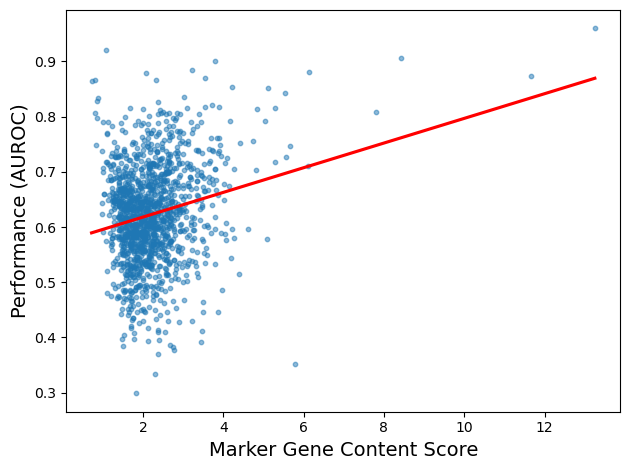

In [ ]:
def plot_bulk(GO_learnabilty_df_mean):
    # Create the plot using seaborn's regplot
    g = sns.regplot(data=GO_learnabilty_df_mean, x='diff_MGC', y='bulk_auc', 
                    scatter_kws={'s': 10, 'alpha': 0.5}, line_kws={'color': 'red'}, ci=None)

    # Add global x and y labels with matplotlib
    plt.xlabel('Marker Gene Content Score', fontsize=14)
    plt.ylabel('Performance (AUROC)', fontsize=14)

    # Adjust layout for tight spacing
    plt.tight_layout()

    # Save the plot as a PNG file with high resolution
    plt.savefig("figs/AUC_MGC_bulk.png", dpi=300)

    # Optionally show the plot
    # plt.show()

plot_bulk(df_normal_brain)

In [ ]:
# Fit OLS model for exp_type == 'exp'
model_exp = smf.ols('bulk_auc ~ diff_MGC', data=df_normal_brain).fit()
r_squared_exp = model_exp.rsquared

# Print the R² values
print(f"R² for bulk: {r_squared_exp}")
print(model_exp.pvalues)

print(model_exp.summary())

R² for bulk: 0.04557491346166842
Intercept    0.000000e+00
diff_MGC     6.971180e-16
dtype: float64
                            OLS Regression Results                            
Dep. Variable:               bulk_auc   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     66.71
Date:                Thu, 06 Mar 2025   Prob (F-statistic):           6.97e-16
Time:                        15:35:33   Log-Likelihood:                 1429.7
No. Observations:                1399   AIC:                            -2855.
Df Residuals:                    1397   BIC:                            -2845.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------